# OptiMystic JupyterLab Integration Test Notebook

This notebook is for testing and debugging, not for Voila web deployment.

It lets you run and debug each layer independently in JupyterLab:
- Python-only (`cp`)
- Julia-only (`mip`, called through the Python CLI)
- R bridge connectivity (`rpy2` + `r_solvers`)
- Full pipeline (Python/Julia -> R post-processing)

In [1]:
# Step 1: Environment bootstrap
import json
import sys
import importlib
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "examples").exists() and (PROJECT_ROOT.parent / "examples").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT / "examples"))
import jupyter_debug_tools as jdt
importlib.reload(jdt)

run_python_only_cp_scheduling = jdt.run_python_only_cp_scheduling
run_julia_only_mip_packing = jdt.run_julia_only_mip_packing
run_full_pipeline = jdt.run_full_pipeline
ensure_r_bridge = jdt.ensure_r_bridge
run_r_postprocess = jdt.run_r_postprocess
explain_debug_pipeline = jdt.explain_debug_pipeline
run_section = jdt.run_section
warmup_julia_path = jdt.warmup_julia_path

print("Project root:", PROJECT_ROOT)
print("Loaded helper module from:", jdt.__file__)
print(json.dumps(explain_debug_pipeline(), indent=2))

Project root: c:\Users\kevin\OneDrive\Desktop\OptiMystic
Loaded helper module from: c:\Users\kevin\OneDrive\Desktop\OptiMystic\examples\jupyter_debug_tools.py
{
  "python_only": "Validate only Python CP scheduling logic (excluding Julia/R)",
  "julia_only": "Validate only Julia MIP execution path (called via Python CLI subprocess)",
  "r_bridge": "Validate rpy2 and r_solvers loading/connectivity",
  "full_pipeline": "End-to-end validation: Python/Julia outputs passed into R process_results",
  "quick_mode": "Use quick=True to run smaller payloads for faster feedback",
  "warmup": "Run warmup_julia_path() once to reduce first-run Julia latency"
}


## What Each Section Tests

- Python-only: validates only Python CP logic
- Julia-only: validates only Julia MIP execution path
- R bridge: validates only `rpy2` and `r_solvers` connectivity
- Full pipeline: validates end-to-end handoff from Python/Julia outputs to R post-processing

This structure helps isolate failures quickly by layer.

In [2]:
# Step 2: Fast Python/Julia checks
print("Warming up Julia path (first run can be slower)...")
warmup = warmup_julia_path()
print(json.dumps(warmup, indent=2))

# Quick targeted run
SECTION = "full"  # "python" | "julia" | "full"
section_result = run_section(SECTION, quick=True)
print(f"Section={SECTION}")
print(json.dumps({k: v.get('status') for k, v in section_result.items()}, indent=2))

Warming up Julia path (first run can be slower)...


{
  "status": "Optimal",
  "objective": 10.0,
  "note": "Julia path warmed up. Next runs are usually faster."
}
Section=full
{
  "python_cp": "Optimal",
  "julia_mip": "Optimal"
}


In [3]:
# Step 3: R bridge check
r_info = ensure_r_bridge()
print(json.dumps(r_info, indent=2))

R callback write-console: <class 'UnicodeDecodeError'> 'utf-8' codec can't decode byte 0xb4 in position 1: invalid start byte <traceback object at 0x000002AF28080A80>
R callback write-console: The following objects are masked from 'package:stats':

    filter, lag

  
R callback write-console: The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union

  


{
  "ok": true,
  "r_version": "R version 4.5.3 (2026-03-11 ucrt)",
  "r_workdir": "C:/Users/kevin/OneDrive/Desktop/OptiMystic/r_solvers"
}


In [4]:
# Step 4: Full pipeline + assertions (dynamic scenario with 8 items)
import subprocess

print("Running full pipeline with dynamic 8-item packing scenario...")

python_cp = run_python_only_cp_scheduling(quick=False)

packing_params = {
    "Items": [
        {"Name": "A", "Weight": 2, "Value": 6},
        {"Name": "B", "Weight": 3, "Value": 9},
        {"Name": "C", "Weight": 4, "Value": 12},
        {"Name": "D", "Weight": 5, "Value": 13},
        {"Name": "E", "Weight": 6, "Value": 16},
        {"Name": "F", "Weight": 7, "Value": 18},
        {"Name": "G", "Weight": 8, "Value": 21},
        {"Name": "H", "Weight": 9, "Value": 24},
    ],
    "Vehicles": [{"Capacity": 15}],
}

cmd = [
    sys.executable,
    str(PROJECT_ROOT / "python_solvers" / "cli_solver.py"),
    "--domain",
    "packing",
    "--solver",
    "mip",
    "--params",
    json.dumps(packing_params),
]
proc = subprocess.run(
    cmd,
    capture_output=True,
    text=True,
    cwd=str(PROJECT_ROOT),
    timeout=180,
)
if proc.returncode != 0:
    raise RuntimeError(proc.stderr.strip() or proc.stdout.strip() or "Packing solve failed")

julia_mip = json.loads(proc.stdout)
pipeline = {"python_cp": python_cp, "julia_mip": julia_mip}

packing_store = {
    "parameters": {
        "Items": [x["Name"] for x in packing_params["Items"]],
        "Weights": [x["Weight"] for x in packing_params["Items"]],
        "Values": [x["Value"] for x in packing_params["Items"]],
        "Capacity": packing_params["Vehicles"][0]["Capacity"],
    }
}
packing_processed = run_r_postprocess("packing", pipeline["julia_mip"], packing_store)

print(json.dumps({
    "python_cp_status": pipeline["python_cp"].get("status"),
    "julia_mip_status": pipeline["julia_mip"].get("status"),
    "r_processed_status": packing_processed.get("status"),
    "selected_items": [x.get("item") for x in packing_processed.get("items", [])],
}, indent=2))

assert pipeline["python_cp"].get("status") not in ("Error", "error")
assert pipeline["julia_mip"].get("status") not in ("Error", "error")
assert packing_processed.get("status") == "ok"
print("All targeted tests passed (Python/Julia/R).")

Running full pipeline with dynamic 8-item packing scenario...
{
  "python_cp_status": "Optimal",
  "julia_mip_status": "Optimal",
  "r_processed_status": "ok",
  "selected_items": [
    "A",
    "B",
    "C",
    "E"
  ]
}
All targeted tests passed (Python/Julia/R).


[Standardized R post-analysis]
{'items': [{'count': 1, 'item': 'B', 'value': 12, 'weight': 3},
           {'count': 1, 'item': 'C', 'value': 14, 'weight': 4}],
 'kpis': {'capacity': 7,
          'total_value': 26,
          'used_capacity': 7,
          'utilization_pct': 100.0},
 'mode': 'packing',
 'objective': 26,
 'report': 'Total Value: 26.00\nUsed Capacity: 7.00 / 7.00 (100.0%)',
 'status': 'ok'}


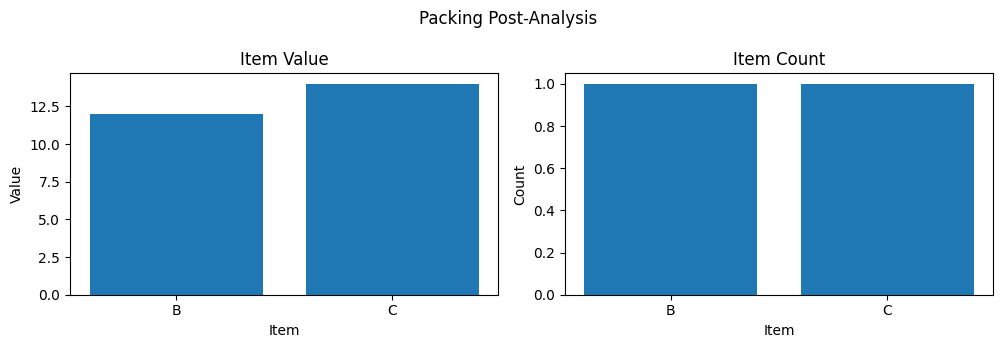

In [ ]:
# Step 5: Standardized post-analysis + efficiency + capacity what-if
from pprint import pprint
import subprocess
import matplotlib.pyplot as plt

normalized = {
    "mode": packing_processed.get("mode"),
    "status": packing_processed.get("status"),
    "objective": packing_processed.get("objective", packing_processed.get("total_value")),
    "kpis": {
        "total_value": packing_processed.get("total_value"),
        "used_capacity": packing_processed.get("used_capacity"),
        "capacity": packing_processed.get("capacity"),
        "utilization_pct": (
            round(100.0 * packing_processed.get("used_capacity", 0) / max(packing_processed.get("capacity", 1), 1), 1)
            if packing_processed.get("capacity") is not None
            else None
        ),
    },
    "items": packing_processed.get("items", []),
    "report": packing_processed.get("report"),
}

print("[Standardized R post-analysis]")
pprint(normalized)

items = normalized["items"] or []
labels = [str(x.get("item", "?")) for x in items]
values = [float(x.get("value", 0) or 0) for x in items]
counts = [float(x.get("count", 0) or 0) for x in items]
weights = [float(x.get("weight", 0) or 0) for x in items]
ratios = [round(v / w, 3) if w else 0.0 for v, w in zip(values, weights)]

# What-if: vary capacity and track objective/utilization from R post-processing
base_items = [
    {"Name": "A", "Weight": 2, "Value": 6},
    {"Name": "B", "Weight": 3, "Value": 9},
    {"Name": "C", "Weight": 4, "Value": 12},
    {"Name": "D", "Weight": 5, "Value": 13},
    {"Name": "E", "Weight": 6, "Value": 16},
    {"Name": "F", "Weight": 7, "Value": 18},
    {"Name": "G", "Weight": 8, "Value": 21},
    {"Name": "H", "Weight": 9, "Value": 24},
]

capacities = [10, 12, 14, 16, 18]
what_if_value = []
what_if_util = []

for cap in capacities:
    params = {"Items": base_items, "Vehicles": [{"Capacity": cap}]}
    cmd = [
        sys.executable,
        str(PROJECT_ROOT / "python_solvers" / "cli_solver.py"),
        "--domain",
        "packing",
        "--solver",
        "mip",
        "--params",
        json.dumps(params),
    ]
    proc = subprocess.run(
        cmd,
        capture_output=True,
        text=True,
        cwd=str(PROJECT_ROOT),
        timeout=180,
    )
    if proc.returncode != 0:
        raise RuntimeError(f"What-if solve failed at capacity={cap}: " + (proc.stderr.strip() or proc.stdout.strip()))
    solved = json.loads(proc.stdout)

    store = {
        "parameters": {
            "Items": [x["Name"] for x in base_items],
            "Weights": [x["Weight"] for x in base_items],
            "Values": [x["Value"] for x in base_items],
            "Capacity": cap,
        }
    }
    post = run_r_postprocess("packing", solved, store)
    total_value = float(post.get("total_value", 0) or 0)
    used_capacity = float(post.get("used_capacity", 0) or 0)
    what_if_value.append(total_value)
    what_if_util.append(round(100.0 * used_capacity / max(cap, 1), 1))

fig, axes = plt.subplots(2, 2, figsize=(12, 7))

if labels:
    axes[0, 0].bar(labels, values, color="#3572A5")
    axes[0, 0].set_title("Selected Item Value")
    axes[0, 0].set_xlabel("Item")
    axes[0, 0].set_ylabel("Value")

    axes[0, 1].bar(labels, counts, color="#5DAE8B")
    axes[0, 1].set_title("Selected Item Count")
    axes[0, 1].set_xlabel("Item")
    axes[0, 1].set_ylabel("Count")

    axes[1, 0].bar(labels, ratios, color="#D68C45")
    axes[1, 0].set_title("Selected Item Efficiency (Value/Weight)")
    axes[1, 0].set_xlabel("Item")
    axes[1, 0].set_ylabel("Value per Weight")
else:
    axes[0, 0].text(0.5, 0.5, "No items", ha="center", va="center")
    axes[0, 1].text(0.5, 0.5, "No items", ha="center", va="center")
    axes[1, 0].text(0.5, 0.5, "No items", ha="center", va="center")

axes[1, 1].plot(capacities, what_if_value, marker="o", label="Total Value")
axes[1, 1].plot(capacities, what_if_util, marker="s", label="Utilization %")
axes[1, 1].set_title("Capacity What-if Sensitivity")
axes[1, 1].set_xlabel("Capacity")
axes[1, 1].set_ylabel("Value / Utilization")
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

fig.suptitle("Packing Post-Analysis Dashboard")
fig.tight_layout()
plt.show()